In [1]:
# Configure path.
import sys; import os
sys.path.append(os.path.abspath('..'))

%matplotlib inline
import numpy as np
import importlib, pickle
import matplotlib.pyplot as plt
plt.style.use('dissertation.mplstyle')

from python import forces, integrators, random_matrix, simulate, densities, plotters, solvers
importlib.reload(forces); importlib.reload(integrators); importlib.reload(random_matrix)
importlib.reload(simulate); importlib.reload(densities); importlib.reload(plotters); importlib.reload(solvers);

---

1. Eigenvalues of a large Hermitian matrix.

In [ ]:
M = 1; N = 5000;
eigs = random_matrix.init_gue_eigenvalues(M, N).flatten()

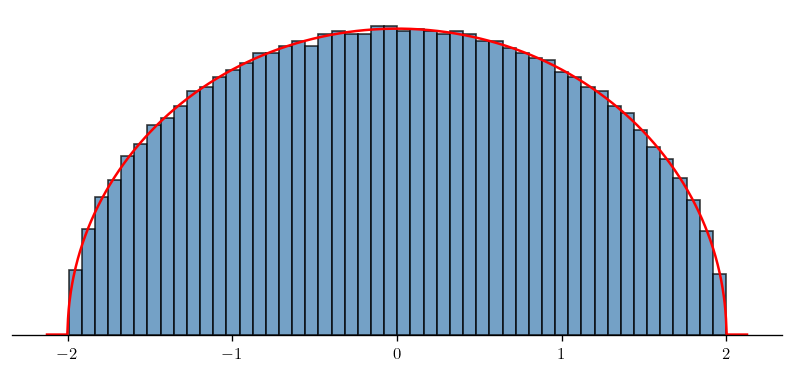

In [10]:
fig, ax = plt.subplots()
plotters.plot_hist(ax, eigs, num_bins = 50, potential_name = "quadratic")

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.set_yticks([])

plt.savefig("figures/eigs-random-N5000.pdf", format = "pdf", dpi = 120)
plt.show()

---

2. Unadjusted methodss.

- Showing the tamed scheme is unstable for long times until $~ \mathcal{O}(N^2)$.
- General histogram/distance plots for the tamed vs implicit vs implicit midpoint algs.
- Looking at Newton info for the implicit methods.

---


In [4]:
# Implicit and implicit midpoint: use dt = 0.1 (O(1)) and track the distance metrics for large N (50, 100, 200)
# then compare this to when using 1/sqrt{N} and 1/N.
# Uses default Newton tol 1e-6 and cg tol 1e-9...
beta = 2.0; T = 10.0; M = 50; pot_name = "quartic"; num_bins = 50
grid = np.linspace(-2, 2, 1000); 

N = 100; init = random_matrix.init_gue_eigenvalues(M, N)
F_exact = densities.compute_exact_cdf(N, pot_name, grid)

# ==========================================================================
# N100 with dt 0.1
dt = 0.1; total_steps = int(T/dt)
config = {"burn_in": int(2.0/dt), "snapshot_interval": 10,
          "track_distance": True, "dt": dt, "grid": grid, "F_exact": F_exact, "distance_type": "ks",
          "track_newton_info": True}
implicit_pipe_1a = simulate.get_pipeline("implicit", N = N, dt = dt, potential_type = pot_name, beta = beta)
implicit_traj_1a = simulate.simulate_dbm(init, total_steps, implicit_pipe_1a)
implicit_info_1a = simulate.analyse_trajectory(implicit_traj_1a, total_steps, **config)

# ==========================================================================
# N100 with dt 1/N
dt = 1/N; total_steps = int(T/dt)
config = {"burn_in": int(2.0/dt), "snapshot_interval": 10,
          "track_distance": True, "dt": dt, "grid": grid, "F_exact": F_exact, "distance_type": "ks",
          "track_newton_info": True}
implicit_pipe_1c = simulate.get_pipeline("implicit", N = N, dt = dt, potential_type = pot_name, beta = beta)
implicit_traj_1c = simulate.simulate_dbm(init, total_steps, implicit_pipe_1c)
implicit_info_1c = simulate.analyse_trajectory(implicit_traj_1c, total_steps, **config)

# ==========================================================================
# N300 with dt 0.1
N = 300
init = random_matrix.init_gue_eigenvalues(M, N)

dt = 0.1; total_steps = int(T/dt)
config = {"burn_in": int(2.0/dt), "snapshot_interval": 10,
          "track_distance": True, "dt": dt, "grid": grid, "F_exact": F_exact, "distance_type": "ks",
          "track_newton_info": True}

implicit_pipe_2a = simulate.get_pipeline("implicit", N = N, dt = dt, potential_type = pot_name, beta = beta)
implicit_traj_2a = simulate.simulate_dbm(init, total_steps, implicit_pipe_2a)
implicit_info_2a = simulate.analyse_trajectory(implicit_traj_2a, total_steps, **config)

print(f"Onto 1/rootN.")
# =========================================================================================================
# N300 with dt 1/rootN
dt = 1/np.sqrt(N); total_steps = int(T/dt)
config = {"burn_in": int(2.0/dt), "snapshot_interval": 10,
          "track_distance": True, "dt": dt, "grid": grid, "F_exact": F_exact, "distance_type": "ks",
          "track_newton_info": True}
implicit_pipe_2b = simulate.get_pipeline("implicit", N = N, dt = dt, potential_type = pot_name, beta = beta)
implicit_traj_2b = simulate.simulate_dbm(init, total_steps, implicit_pipe_2b)
implicit_info_2b = simulate.analyse_trajectory(implicit_traj_2b, total_steps, **config)

print(f"Onto 1/N.")
# =========================================================================================================
# N300 with dt 1/N
dt = 1/N; total_steps = int(T/dt)
config = {"burn_in": int(2.0/dt), "snapshot_interval": 10,
          "track_distance": True, "dt": dt, "grid": grid, "F_exact": F_exact, "distance_type": "ks",
          "track_newton_info": True}
implicit_pipe_2c = simulate.get_pipeline("implicit", N = N, dt = dt, potential_type = pot_name, beta = beta)
implicit_traj_2c = simulate.simulate_dbm(init, total_steps, implicit_pipe_2c)
implicit_info_2c = simulate.analyse_trajectory(implicit_traj_2c, total_steps, **config)

Onto 1/rootN.
Onto 1/N.


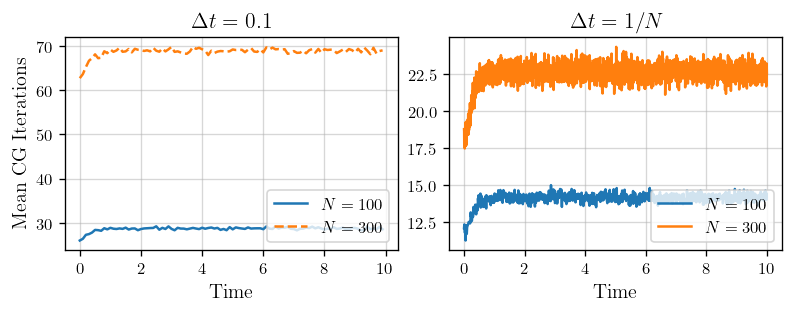

In [7]:
fig, axes = plt.subplots(1, 2, figsize = (6.5, 2.5))
ax1, ax2 = axes 

dt = 0.1; step_times_O1 = [step*dt for step in range(int(T/dt))]
dt = 1/100; step_times_N100 = [step*dt for step in range(int(T/dt))]
dt = 1/300; step_times_N300 = [step*dt for step in range(int(T/dt))]

ax1.plot(step_times_O1, implicit_info_1a["mean_cg_iters"].mean(axis = 1), label = r"$N = 100$", lw = 1.5)
ax1.plot(step_times_O1, implicit_info_2a["mean_cg_iters"].mean(axis = 1), label = r"$N = 300$", lw = 1.5, linestyle = "--")
ax2.plot(step_times_N100, implicit_info_1c["mean_cg_iters"].mean(axis = 1), label = r"$N = 100$", lw = 1.5)
ax2.plot(step_times_N300, implicit_info_2c["mean_cg_iters"].mean(axis = 1), label = r"$N = 300$", lw = 1.5)

ax1.set_ylabel("Mean CG Iterations")
ax1.set_title(r"$\Delta t = 0.1$")
ax2.set_title(r"$\Delta t = 1/N$")

for ax in axes:
    ax.legend(loc = "lower right")
    ax.set_xlabel("Time")

plt.show()

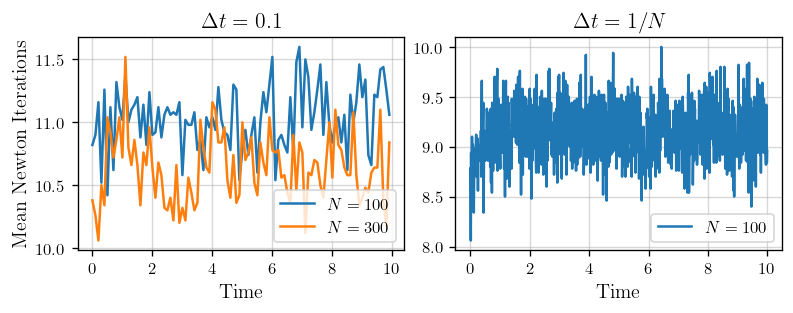

In [14]:
fig, axes = plt.subplots(1, 2, figsize = (6.5, 2.5))
ax1, ax2 = axes 

ax1.plot(step_times_O1, implicit_info_1a["newton_iters"].mean(axis = 1), label = r"$N = 100$", lw = 1.5)
ax1.plot(step_times_O1, implicit_info_2a["newton_iters"].mean(axis = 1), label = r"$N = 300$", lw = 1.5)
ax2.plot(step_times_N100, implicit_info_1c["newton_iters"].mean(axis = 1), label = r"$N = 100$", lw = 1.5)
# ax2.plot(step_times_N300, implicit_info_2c["newton_iters"].mean(axis = 1), label = r"$N = 300$", lw = 1.5)

for ax in axes:
    ax.legend(loc = "lower right")
    ax.set_xlabel("Time")

ax1.set_ylabel("Mean Newton Iterations")
ax1.set_title(r"$\Delta t = 0.1$")
ax2.set_title(r"$\Delta t = 1/N$")

plt.show()

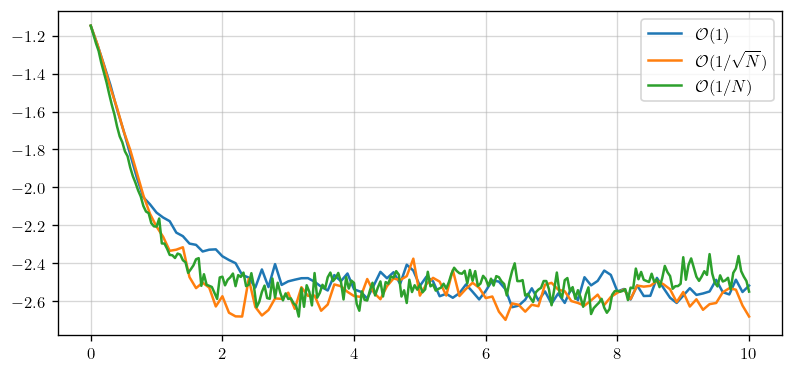

In [13]:
# For N = 100, 0.1 and 1/root(100) are the same!
fig, ax = plt.subplots(1, 1, figsize = (6.5, 3))
importlib.reload(plotters);
plotters.plot_distances(ax, implicit_info_1a, label = r"$\mathcal{O}(1)$")
plotters.plot_distances(ax, implicit_info_1b, label = r"$\mathcal{O}(1/\sqrt{N})$")
plotters.plot_distances(ax, implicit_info_1c, label = r"$\mathcal{O}(1/N)$")

ax.legend()
plt.show()

Run again for larger $N$, still implicit (try $N = 300$, e.g.).

In [14]:
# Implicit and implicit midpoint: use dt = 0.1 (O(1)) and track the distance metrics for large N (50, 100, 200)
# then compare this to when using 1/sqrt{N} and 1/N.
# Uses default Newton tol 1e-6 and cg tol 1e-9...
beta = 2.0; T = 10.0; M = 50; pot_name = "quartic"; num_bins = 50
grid = np.linspace(-2, 2, 1000); 

N = 300; init = random_matrix.init_gue_eigenvalues(M, N)
F_exact = densities.compute_exact_cdf(N, pot_name, grid)

dt = 0.1; total_steps = int(T/dt)
config = {"burn_in": int(2.0/dt), "snapshot_interval": 10,
          "track_distance": True, "dt": dt, "grid": grid, "F_exact": F_exact, "distance_type": "ks",
          "track_newton_info": True}
implicit_pipe_2a = simulate.get_pipeline("implicit", N = N, dt = dt, potential_type = pot_name, beta = beta)
implicit_traj_2a = simulate.simulate_dbm(init, total_steps, implicit_pipe_2a)
implicit_info_2a = simulate.analyse_trajectory(implicit_traj_2a, total_steps, **config)

print(f"Onto 1/rootN.")
# =========================================================================================================
dt = 1/np.sqrt(N); total_steps = int(T/dt)
config = {"burn_in": int(2.0/dt), "snapshot_interval": 10,
          "track_distance": True, "dt": dt, "grid": grid, "F_exact": F_exact, "distance_type": "ks",
          "track_newton_info": True}
implicit_pipe_2b = simulate.get_pipeline("implicit", N = N, dt = dt, potential_type = pot_name, beta = beta)
implicit_traj_2b = simulate.simulate_dbm(init, total_steps, implicit_pipe_2b)
implicit_info_2b = simulate.analyse_trajectory(implicit_traj_2b, total_steps, **config)

print(f"Onto 1/N.")
# =========================================================================================================
dt = 1/N; total_steps = int(T/dt)
config = {"burn_in": int(2.0/dt), "snapshot_interval": 10,
          "track_distance": True, "dt": dt, "grid": grid, "F_exact": F_exact, "distance_type": "ks",
          "track_newton_info": True}
implicit_pipe_2c = simulate.get_pipeline("implicit", N = N, dt = dt, potential_type = pot_name, beta = beta)
implicit_traj_2c = simulate.simulate_dbm(init, total_steps, implicit_pipe_2c)
implicit_info_2c = simulate.analyse_trajectory(implicit_traj_2c, total_steps, **config)

Onto 1/rootN.
Onto 1/N.


N = 100-300, M = 50, T = 10, all implicit.


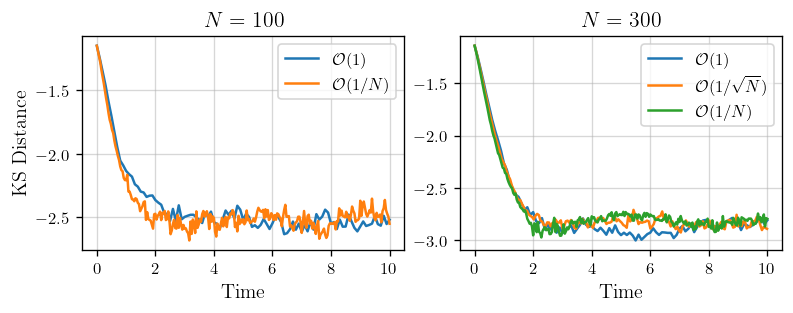

In [57]:
print(f"N = 100-300, M = 50, T = 10, all implicit.")

fig, axes = plt.subplots(1, 2, figsize = (6.5, 2.5))
ax, ax2 = axes

plotters.plot_distances(ax, implicit_info_1a, label = r"$\mathcal{O}(1)$")
plotters.plot_distances(ax, implicit_info_1c, label = r"$\mathcal{O}(1/N)$")

plotters.plot_distances(ax2, implicit_info_2a, label = r"$\mathcal{O}(1)$")
plotters.plot_distances(ax2, implicit_info_2b, label = r"$\mathcal{O}(1/\sqrt{N})$")
plotters.plot_distances(ax2, implicit_info_2c, label = r"$\mathcal{O}(1/N)$")

ax.set_title(r"$N = 100$")
ax2.set_title(r"$N = 300$")
ax.set_ylabel("KS Distance")

for ax in axes:
    ax.legend()
    ax.set_xlabel("Time")

plt.savefig("a-implicit_N100-300-T10-distances.pdf", format = "pdf", dpi = 120)
plt.show()

Does the step size influence the number of Newton/CG iterations needed as $N$ grows?

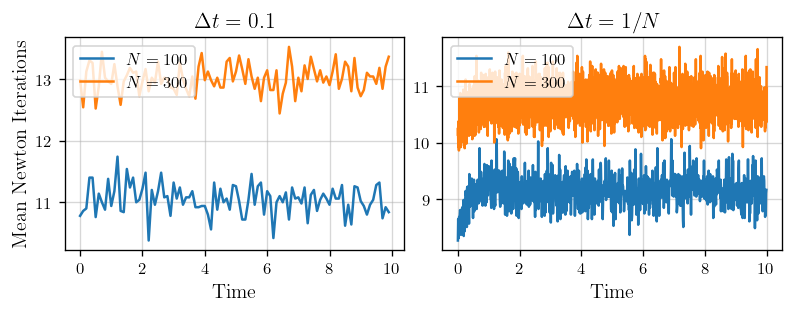

In [64]:
dt = 0.1; step_times_O1 = [step*dt for step in range(int(T/dt))]
dt = 1/100; step_times_N100 = [step*dt for step in range(int(T/dt))]
dt = 1/300; step_times_N300 = [step*dt for step in range(int(T/dt))]

fig, axes = plt.subplots(1, 2, figsize = (6.5, 2.5))
ax1, ax2 = axes 

ax1.plot(step_times_O1, implicit_info_1a["newton_iters"].mean(axis = 1), label = r"$N = 100$", lw = 1.5)
ax1.plot(step_times_O1, implicit_info_2a["newton_iters"].mean(axis = 1), label = r"$N = 300$", lw = 1.5)
ax2.plot(step_times_N100, implicit_info_1c["newton_iters"].mean(axis = 1), label = r"$N = 100$", lw = 1.5)
ax2.plot(step_times_N300, implicit_info_2c["newton_iters"].mean(axis = 1), label = r"$N = 300$", lw = 1.5)

for ax in axes:
    ax.legend(loc = "upper left")
    ax.set_xlabel("Time")

ax1.set_ylabel("Mean Newton Iterations")
ax1.set_title(r"$\Delta t = 0.1$")
ax2.set_title(r"$\Delta t = 1/N$")


plt.savefig("implicit-newton-iters.pdf", format = "pdf", dpi = 120)
plt.show()

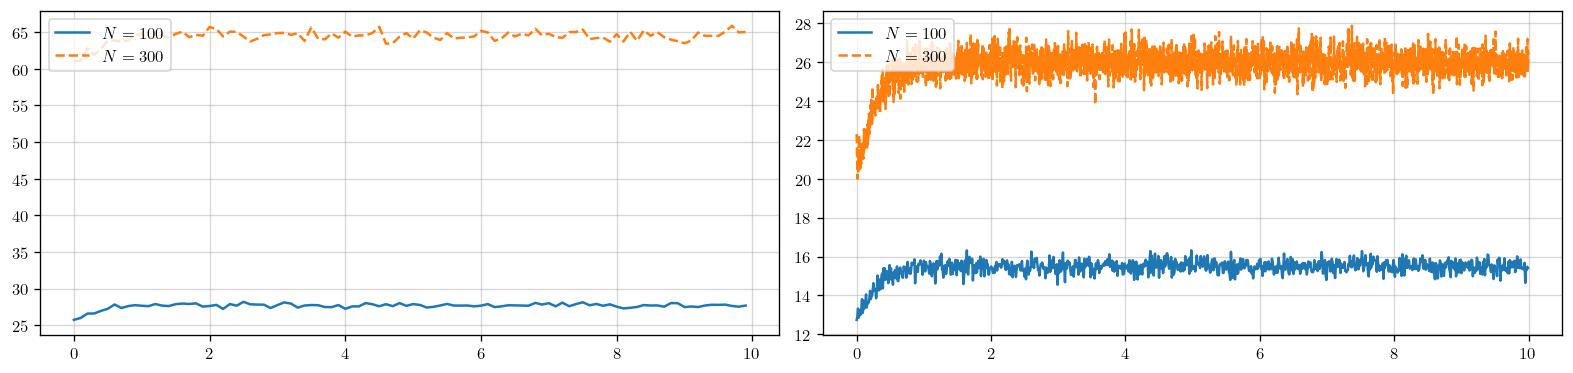

In [50]:
fig, axes = plt.subplots(1, 2, figsize = (13, 3))
ax1, ax2 = axes 
dt = 0.1; step_times_O1 = [step*dt for step in range(int(T/dt))]
dt = 1/100; step_times_N100 = [step*dt for step in range(int(T/dt))]
dt = 1/300; step_times_N300 = [step*dt for step in range(int(T/dt))]

ax1.plot(step_times_O1, implicit_info_1a["mean_cg_iters"].mean(axis = 1), label = r"$N = 100$", lw = 1.5)
ax1.plot(step_times_O1, implicit_info_2a["mean_cg_iters"].mean(axis = 1), label = r"$N = 300$", lw = 1.5, linestyle = "--")
ax2.plot(step_times_N100, implicit_info_1c["mean_cg_iters"].mean(axis = 1), label = r"$N = 100$", lw = 1.5)
ax2.plot(step_times_N300, implicit_info_2c["mean_cg_iters"].mean(axis = 1), label = r"$N = 300$", lw = 1.5, linestyle = "--")

for ax in axes:
    ax.legend(loc = "upper left")

plt.show()

In [19]:
implicit_N100 = {
    "N": 100, "M": 50, "T": 10,
    "dt-O1": implicit_info_1a,
    "dt-O1overN": implicit_info_1c
}

implicit_N300 = {
    "N": 300, "M": 50, "T": 10,
    "dt-O1": implicit_info_2a,
    "dt-O1rootN": implicit_info_2b,
    "dt-O1overN": implicit_info_2c
}

all_implicit_data = {
    "N100": implicit_N100,
    "N300": implicit_N300,
    "M": 50, "T": 10, 
}

filename = f"data/implicit-N100-300.pkl"
with open(filename, 'wb') as f:
    pickle.dump(all_implicit_data, f)

---
---
---
---
---

Spacings (Wigner Surmsie).

Beta 1, mean accepts 0.27.
Beta 2, mean accepts 0.50.
Beta 4, mean accepts 0.55.


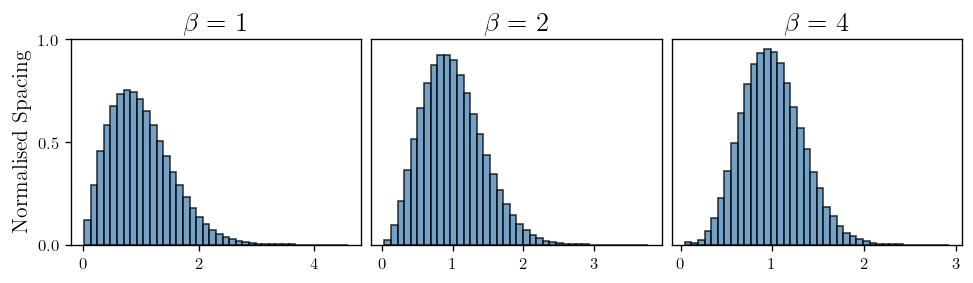

In [10]:
fig, axes = plt.subplots(1, 3, figsize = (8, 2.25))

N = 100; T = 5.0; pot = "quadratic"; M = 50;
betas = [1, 2, 4]; dts = [1/(8*N), 1/(4*N), 1/(2*N)]
config = {"burn_in": 0, "track_accepts": True, 
        "track_spacings": True, "F_cdf": densities.exact_semicircle_cdf}

init = random_matrix.init_gue_eigenvalues(M, N)
for j, beta in enumerate(betas):
    dt = dts[j]; total_steps = int(T/dt)
    pipe = simulate.make_mala_pipeline(N, dt, pot, beta)
    trajectory = simulate.simulate_dbm(init, total_steps, pipe)
    info = simulate.analyse_trajectory(trajectory, total_steps, **config)

    print(f"Beta {beta}, mean accepts {info["accepts"].mean():.2f}.")
    plotters.plot_spacings(axes[j], info["spacings"], beta = beta, num_bins = 40, with_limit = False)
    axes[j].set_title(rf"$\beta = $ {beta}", fontsize = 16)

ax1, ax2, ax3 = axes
ax2.set_yticks([]); ax3.set_yticks([]);
ax1.set_ylabel("Normalised Spacing", fontsize = 13)

plt.savefig("mean_spacings_pre_surmise-2.pdf", format = "pdf", dpi = 120)
plt.show()

Beta 1, mean accepts 0.27.
Beta 2, mean accepts 0.49.
Beta 4, mean accepts 0.54.


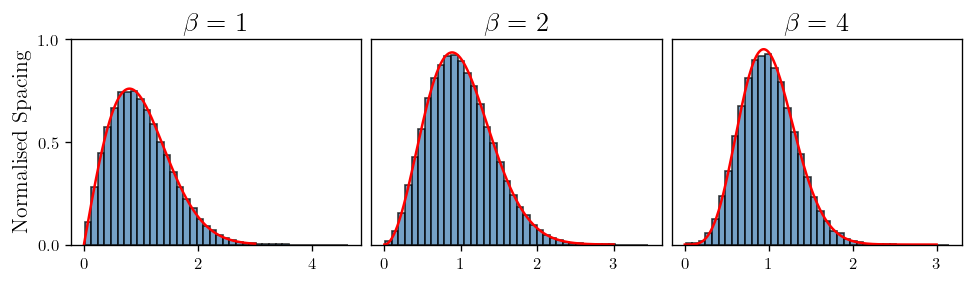

In [12]:
importlib.reload(plotters);
fig, axes = plt.subplots(1, 3, figsize = (8, 2.25))

N = 100; T = 5.0; pot = "quadratic"; M = 50;
betas = [1, 2, 4]; dts = [1/(8*N), 1/(4*N), 1/(2*N)]
config = {"burn_in": 0, "track_accepts": True, 
        "track_spacings": True, "F_cdf": densities.exact_semicircle_cdf}

init = random_matrix.init_gue_eigenvalues(M, N)
for j, beta in enumerate(betas):
    dt = dts[j]; total_steps = int(T/dt)
    pipe = simulate.make_mala_pipeline(N, dt, pot, beta)
    trajectory = simulate.simulate_dbm(init, total_steps, pipe)
    info = simulate.analyse_trajectory(trajectory, total_steps, **config)

    print(f"Beta {beta}, mean accepts {info["accepts"].mean():.2f}.")
    plotters.plot_spacings(axes[j], info["spacings"], beta = beta, num_bins = 40, with_limit = True)
    axes[j].set_title(rf"$\beta = $ {beta}", fontsize = 16)

ax1, ax2, ax3 = axes
ax2.set_yticks([]); ax3.set_yticks([]);
ax1.set_ylabel("Normalised Spacing", fontsize = 13)

plt.savefig("mean_spacings_with_surmise.pdf", format = "pdf", dpi = 120)
plt.show()

---

In [125]:
# Simulating say N = 8 particles on the line - Brownian motion vs DBM, time on x, position on y.
# x_next = sqrt(2dt)*random 

def brownian_step(x, dt):
    noise = np.random.normal(0, 1, x.shape)
    noise_scale = np.sqrt(2*dt)
    confinement = 1/2*x

    return x - confinement*dt + noise_scale*noise 

def dbm_repulsion(x):
    N = x.shape[0]
    repulsion = np.zeros(N)

    for i in range(N):
        for j in range(N):
            if (i != j):
                repulsion[i] += 1.0/(x[i] - x[j])

    return repulsion/N

def dbm_step(x, dt, beta):
    noise = np.random.normal(0, 1, x.shape)
    noise_scale = np.sqrt(2*dt/(beta*N))
    repulsion = dbm_repulsion(x)
    confinement = 1/2*x

    return x + (repulsion - confinement)*dt + noise_scale*noise

# ================================
N = 5; dt = 0.01; T = 5; 
num_steps = int(T/dt);

history = np.zeros((N, num_steps))
history_dbm_weak = np.zeros((N, num_steps))
history_dbm_strong = np.zeros((N, num_steps))

init = np.random.uniform(-1.75, 1.75, N)
history[:, 0] = init; history_dbm_weak[:, 0] = init; history_dbm_strong[:, 0] = init

for j in range(1, num_steps):
    history[:, j] = brownian_step(history[:, j - 1], dt)
    history_dbm_weak[:, j] = dbm_step(history_dbm_weak[:, j - 1], dt, beta = 1.0)
    history_dbm_strong[:, j] = dbm_step(history_dbm_strong[:, j - 1], dt, beta = 4.0)

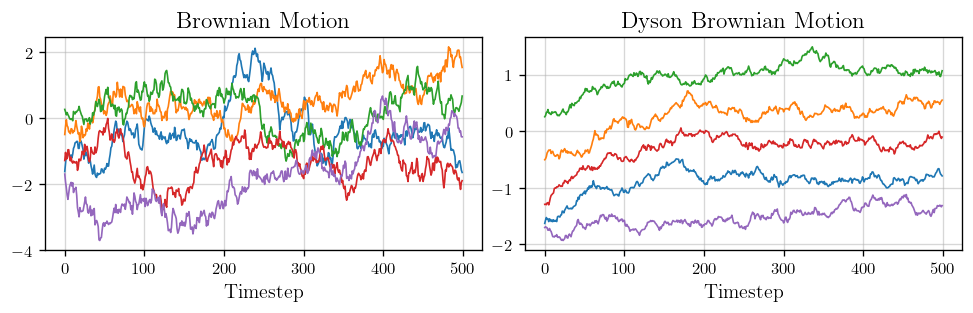

In [129]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (8, 2.5))
for j in range(N):
    lw = 1
    ax1.plot(history[j, :], lw = lw)
    ax2.plot(history_dbm_strong[j, :], lw = lw)

ax1.set_title("Brownian Motion", fontsize = 14)
ax2.set_title("Dyson Brownian Motion", fontsize = 14)

for ax in [ax1, ax2]:
    ax.set_xlabel("Timestep", fontsize = 12)

plt.savefig("bm-vs-dbm.pdf", format = "pdf", dpi = 120)
plt.show()

---

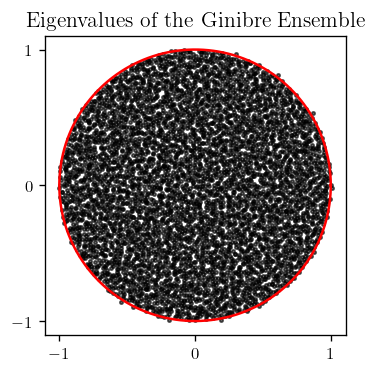

In [ ]:
N = 5000
sigma2 = 1/N 
std = np.sqrt(sigma2/2)

M = np.random.normal(0, std, size = (N, N)) + 1j*np.random.normal(0, std, size = (N ,N))
eigs = np.linalg.eigvals(M)

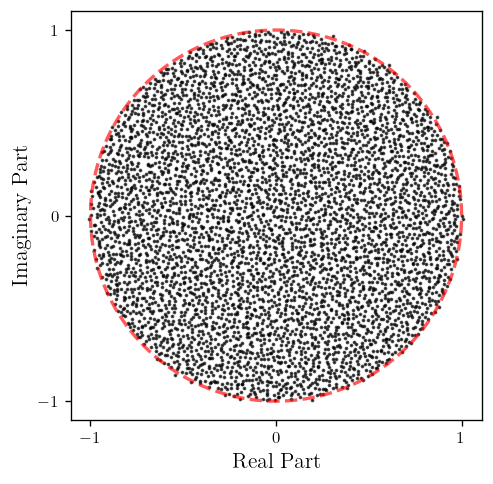

In [36]:
fig, ax = plt.subplots(figsize = (4, 4))
theta = np.linspace(0, 2*np.pi, 1000)
ax.plot(np.cos(theta), np.sin(theta), color="red", lw=2, ls = "--", alpha = 0.65)
# ax.fill(np.cos(theta), np.sin(theta), color="red", alpha=0.08)

ax.scatter(eigs.real, eigs.imag, s = 1.5, alpha = 0.65, color = "black", label = "Eigenvalues")

ax.set_aspect("equal")
# ax.set_title(f"The Circular Law", fontsize = 17, fontweight = "bold")
ax.set_xlabel("Real Part", fontsize = 13)
ax.set_ylabel("Imaginary Part", fontsize = 13)
ax.grid(False)
ax.set_xticks([-1, 0, 1])
ax.set_yticks([-1, 0, 1])

plt.savefig("circulaw-law.pdf", format = "pdf", dpi = 120)

plt.show()


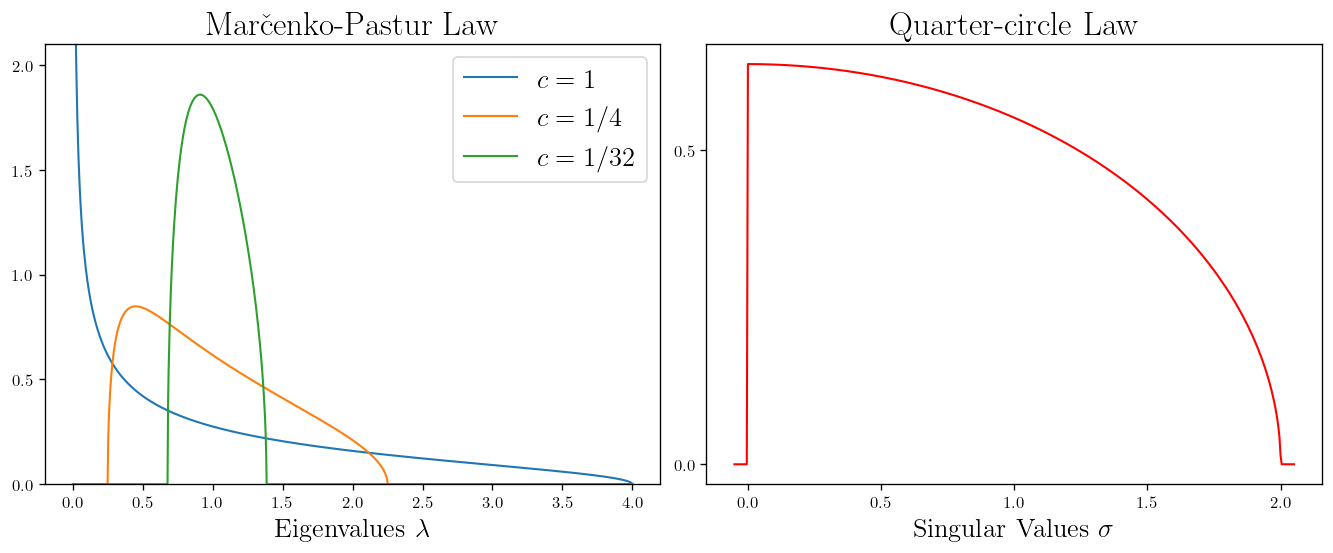

In [ ]:
def marchenko_pastur_density(lam, c):
    lam = np.asarray(lam, dtype = float)
    a = (1 - np.sqrt(c))**2
    b = (1 + np.sqrt(c))**2

    density = np.zeros_like(lam)
    support = (lam >= a) & (lam <= b) & (lam > 0)
    density[support] = (1.0 / (2*np.pi*c*lam[support])) * np.sqrt((lam[support]-a)*(b-lam[support]))
    return density, a, b

def quarter_circle_density(sigma):
    sigma = np.asarray(sigma, dtype = float)
    density = np.zeros_like(sigma)
    support = (sigma >= 0) & (sigma <= 2)
    density[support] = (1.0/np.pi) * np.sqrt(4 - sigma[support]**2)
    return density

# =============================
lam_grid = np.linspace(0.001, 4, 1000)
mp_density, a, b = marchenko_pastur_density(lam_grid, c = 0.5)

sigma_grid = np.linspace(-0.05, 2.05, 500)
qc_density = quarter_circle_density(sigma_grid)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

cs = [1, 1/4, 1/32]
for j, c in enumerate(cs):  
    if (c == 1/32):
        c_lab = r"$c = 1/32$"
    elif (c == 1/4):
        c_lab = r"$c = 1/4$"
    else:
        c_lab = r"$c = 1$"

    axes[0].plot(lam_grid, marchenko_pastur_density(lam_grid, c = c)[0], label = c_lab, linestyle = "-")

axes[0].set_ylim(0, 2.1)
axes[0].set_title(r"Marčenko-Pastur Law", fontsize = 20, fontweight = "bold")
axes[0].set_xlabel(r"Eigenvalues $\lambda$", fontsize = 16, fontweight = "bold")
axes[0].legend(loc = "upper right", fontsize = 16)
axes[0].set_yticks([0, 0.5, 1, 1.5, 2])

axes[1].plot(sigma_grid, qc_density, color="red")
axes[1].set_title("Quarter-circle Law", fontsize = 20, fontweight = "bold")
axes[1].set_xlabel(r"Singular Values $\sigma$", fontsize = 16, fontweight = "bold")
axes[1].set_yticks([0, 0.5])

for ax in axes:
    ax.grid(False)
    
plt.savefig("marchenko-pastur.pdf", format = "pdf", dpi = 120)
plt.show()

---

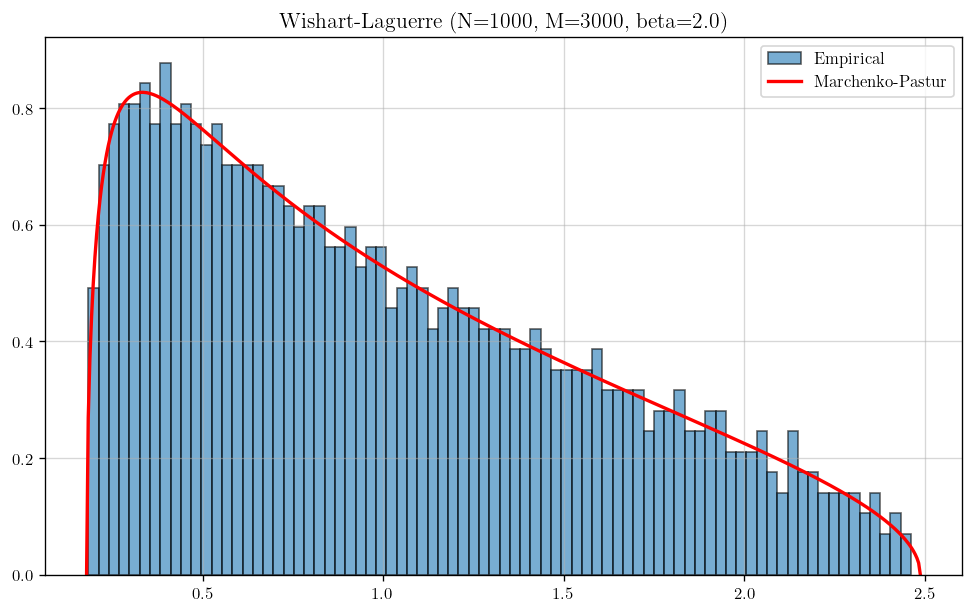

In [8]:
N, M, beta = 1000, 3000, 2.0
c = N / M

diag = np.sqrt(np.random.chisquare(beta * (M - np.arange(N))))
subdiag = np.sqrt(np.random.chisquare(beta * (N - np.arange(1, N))))
X = np.diag(diag) + np.diag(subdiag, k=-1)
L = X @ X.T

evals = np.linalg.eigvalsh(L/ (beta*M)) 

plt.figure(figsize=(8, 5))
plt.hist(evals, bins=80, density=True, alpha=0.6, edgecolor='black', label='Empirical')

x = np.linspace((1 - np.sqrt(c))**2, (1 + np.sqrt(c))**2, 500)
y = np.sqrt(((1 + np.sqrt(c))**2 - x) * (x - (1 - np.sqrt(c))**2)) / (2 * np.pi * c * x)

plt.plot(x, y, 'r-', lw=2, label='Marchenko-Pastur')
plt.title(f"Wishart-Laguerre (N={N}, M={M}, beta={beta})")
plt.legend()
plt.show()